# OIDN denoising

Objective: run Intel Open Image Denoise on a noisy image and see how well a pretrained, non-learned-by-us filter cleans it up.

OIDN isn't a generative model. It just maps a noisy image to a cleaner one in a single forward pass through a small pretrained CNN baked into the OIDN runtime.

In [1]:
import sys
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from oidn.inference import denoise, add_synthetic_noise, SAMPLE_NOISY

RESULTS_DIR = PROJECT_ROOT / "results" / "oidn"
SAMPLE_CLEAN = PROJECT_ROOT / "oidn" / "sample_images" / "sample_clean.png"


## Input image

Bundled sample: a synthetic test image with visible Gaussian noise, plus the clean version of the same image (`sample_clean.png`) used below as a ground truth for measuring how much OIDN actually helps.

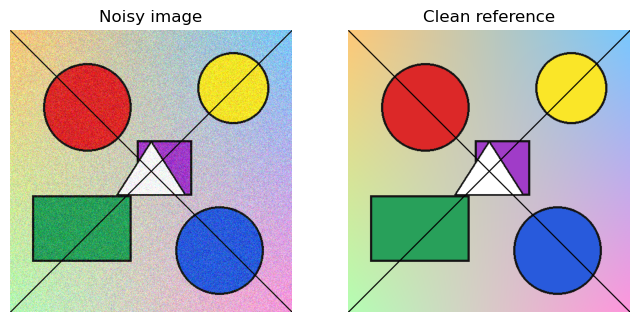

In [2]:
noisy_image = Image.open(SAMPLE_NOISY)
clean_image = Image.open(SAMPLE_CLEAN)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(noisy_image)
axes[0].set_title("Noisy image")
axes[0].axis("off")
axes[1].imshow(clean_image)
axes[1].set_title("Clean reference")
axes[1].axis("off")
plt.show()


## Run OIDN

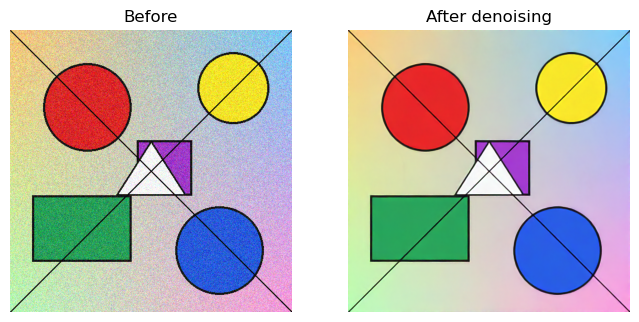

In [3]:
denoised_image = denoise(noisy_image)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
denoised_image.save(RESULTS_DIR / "sample_denoised.png")  # regenerates the exact image used in the README

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(noisy_image)
axes[0].set_title("Before")
axes[0].axis("off")
axes[1].imshow(denoised_image)
axes[1].set_title("After denoising")
axes[1].axis("off")
plt.show()


## Quantitative results

Denoising doesn't have an "accuracy" the way a classifier does, but it has a widely-used equivalent: how close the result is to a known clean reference, measured in **MSE** (mean squared error, lower is better) and **PSNR** (peak signal-to-noise ratio in dB, higher is better). Computing both for the noisy image and the denoised result, against the real clean image, gives an actual number for "how much did OIDN help" instead of just eyeballing it.

In [4]:
def mse(a: Image.Image, b: Image.Image) -> float:
    arr_a = np.asarray(a.convert("RGB"), dtype=np.float64)
    arr_b = np.asarray(b.convert("RGB"), dtype=np.float64)
    return float(np.mean((arr_a - arr_b) ** 2))


def psnr(a: Image.Image, b: Image.Image) -> float:
    error = mse(a, b)
    if error == 0:
        return float("inf")
    return 10 * np.log10((255.0 ** 2) / error)


noisy_mse, noisy_psnr = mse(noisy_image, clean_image), psnr(noisy_image, clean_image)
denoised_mse, denoised_psnr = mse(denoised_image, clean_image), psnr(denoised_image, clean_image)

print(f"Noisy    vs clean -- MSE: {noisy_mse:8.2f}   PSNR: {noisy_psnr:5.2f} dB")
print(f"Denoised vs clean -- MSE: {denoised_mse:8.2f}   PSNR: {denoised_psnr:5.2f} dB")
print()
print(f"PSNR improvement from OIDN: {denoised_psnr - noisy_psnr:+.2f} dB")


Noisy    vs clean -- MSE:   563.64   PSNR: 20.62 dB
Denoised vs clean -- MSE:   127.72   PSNR: 27.07 dB

PSNR improvement from OIDN: +6.45 dB


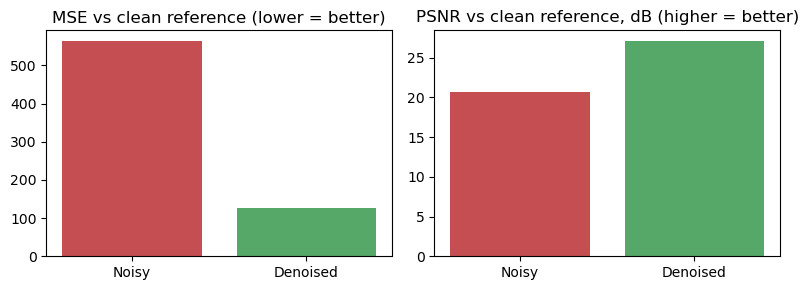

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].bar(["Noisy", "Denoised"], [noisy_mse, denoised_mse], color=["#C44E52", "#55A868"])
axes[0].set_title("MSE vs clean reference (lower = better)")

axes[1].bar(["Noisy", "Denoised"], [noisy_psnr, denoised_psnr], color=["#C44E52", "#55A868"])
axes[1].set_title("PSNR vs clean reference, dB (higher = better)")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "metrics.png", bbox_inches="tight")
plt.show()


## Trying it on a different noise level

Adding heavier synthetic noise to the *actual clean image* this time (not the already-noisy sample), so we can measure OIDN's effect at a noise level worse than the bundled sample.

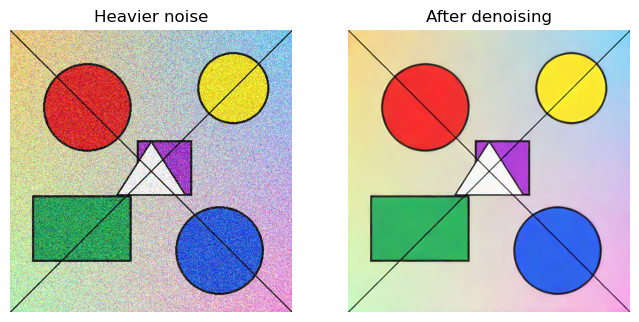

Heavier noise vs clean    -- PSNR: 16.13 dB
Heavier denoised vs clean -- PSNR: 22.85 dB


In [6]:
heavier_noise = add_synthetic_noise(clean_image, sigma=45)
heavier_denoised = denoise(heavier_noise)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(heavier_noise)
axes[0].set_title("Heavier noise")
axes[0].axis("off")
axes[1].imshow(heavier_denoised)
axes[1].set_title("After denoising")
axes[1].axis("off")
plt.show()

print(f"Heavier noise vs clean    -- PSNR: {psnr(heavier_noise, clean_image):5.2f} dB")
print(f"Heavier denoised vs clean -- PSNR: {psnr(heavier_denoised, clean_image):5.2f} dB")


## Observations

OIDN cleans up the flat, noisy background well and keeps hard shape edges mostly intact, which shows up as a clear PSNR improvement over the noisy input, not just a visual impression. It's a single pretrained filter -- no training loop here, no dataset, just inference. That also means it can't do anything a VAE or GAN can (like generating a new image), it only cleans up what's already there. At the heavier noise level, OIDN still helps, but by a smaller margin -- a single denoising pass has limits, especially for a filter tuned for ray-traced renders rather than this kind of synthetic test pattern.